# Plot cluster annotations

Loads Loop 0 data and visualizes UMAPs colored by the different clustering/annotation columns (leiden, leiden_sub, leiden_old, cell_type).

In [5]:
import scanpy as sc

In [6]:
H5AD_PATH = "../../../project_folder/derived/loop1_annotated_500k.h5ad"
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

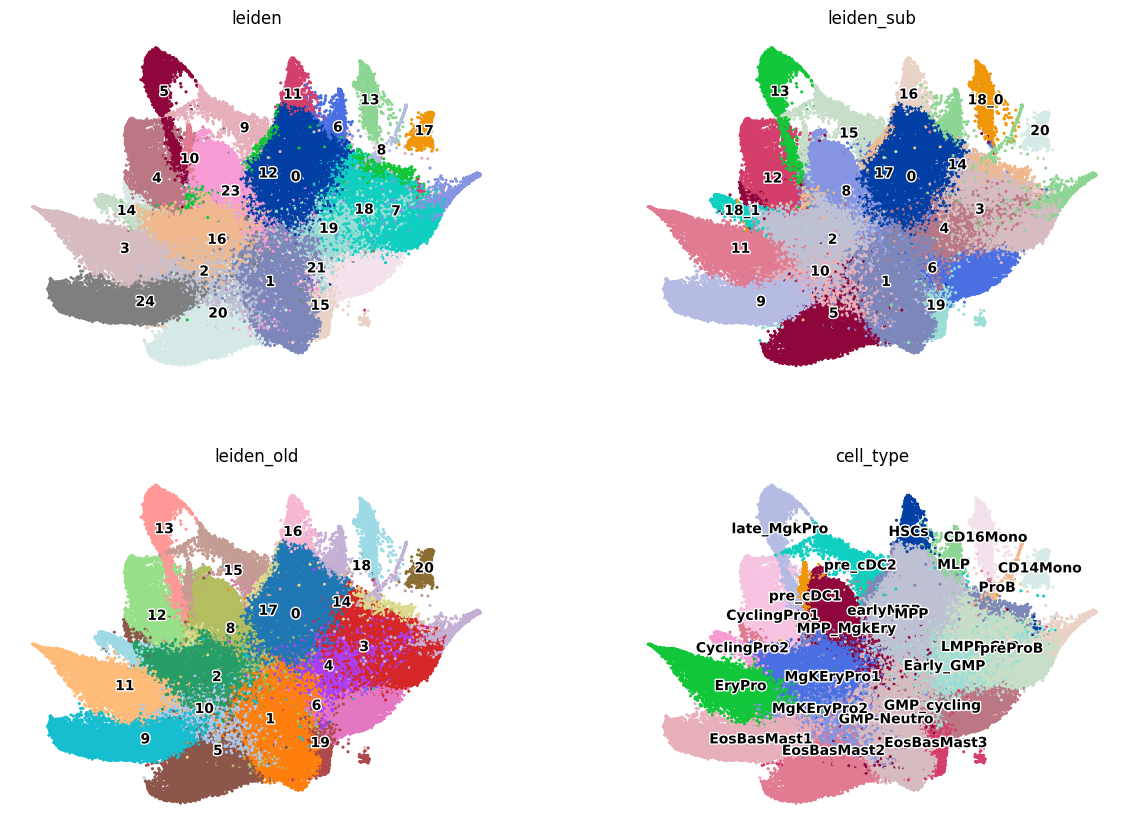

In [7]:
sc.pl.umap(
    adata, 
    color=["leiden", "leiden_sub", "leiden_old", "cell_type"],
    size=20,                 # Increase dot size (default is roughly 120000 / n_cells)
    legend_loc="on data",    # Overlays labels on the cluster centroids
    legend_fontsize=10,      # Adjust label size for clarity
    legend_fontoutline=2,    # Adds a white outline to make labels pop against colors
    frameon=False,           # Optional: removes the plot border for a cleaner look
    ncols=2                  # Arranges plots in 2 columns
)

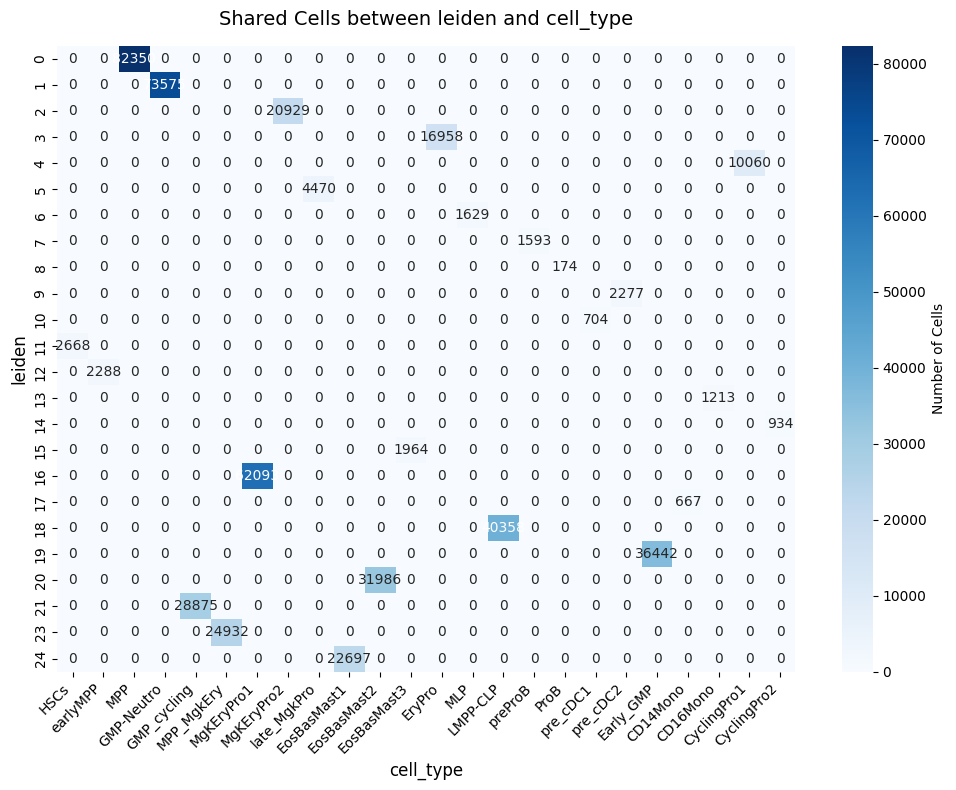

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_shared_labels(adata, annot_1="leiden_old", annot_2="leiden_sub"):
    # 1. Create a cross-tabulation table (counts the overlapping cells)
    overlap_matrix = pd.crosstab(adata.obs[annot_1], adata.obs[annot_2])
    
    # 2. Set up the plot size based on the number of clusters
    plt.figure(figsize=(10, 8))
    
    # 3. Plot the heatmap
    # fmt='d' ensures the numbers are displayed as plain integers (not scientific notation)
    sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    
    # 4. Add labels and title
    plt.title(f'Shared Cells between {annot_1} and {annot_2}', fontsize=14, pad=15)
    plt.xlabel(annot_2, fontsize=12)
    plt.ylabel(annot_1, fontsize=12)

    # Rotate x-axis labels if they are long
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Run it on your specific annotations
plot_shared_labels(adata, "leiden", "cell_type")